In [ ]:
import sys
 
!{sys.executable} -m pip install -q "langchain-core<0.4.0" "langchain>=0.3.0" "langchain-community" "langchain-chroma" "chromadb" "sentence-transformers" "google-generativeai==0.7.2" "langchain-google-genai==2.0.0" pandas matplotlib seaborn scikit-learn

In [ ]:
import os
import time
import getpass
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.chains.retrieval import create_retrieval_chain
from langchain.chains.combine_documents import create_stuff_documents_chain
from langchain_core.prompts import ChatPromptTemplate


if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("MY_API_KEY: ")

In [3]:
SOURCE_DIR = "./knowledge_source"
DB_DIR = "./chroma_db_storage"

 
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

def build_vector_store():
     
    if not os.path.exists(SOURCE_DIR):
        os.makedirs(SOURCE_DIR)
        print(f"Created directory: {SOURCE_DIR}. Please add your .txt files and rerun.")
        return None
        
    loader = DirectoryLoader(SOURCE_DIR, glob="*.txt", loader_cls=TextLoader)
    docs = loader.load()
    
    if not docs:
        print("No documents found in the source directory.")
        return None
        
    splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
    chunks = splitter.split_documents(docs)
    
    print(f"Indexing {len(chunks)} chunks into ChromaDB...")
    return Chroma.from_documents(documents=chunks, embedding=embeddings, persist_directory=DB_DIR)

db = build_vector_store()

C:\Users\visha\AppData\Local\Temp\ipykernel_7176\318784922.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Indexing 2 chunks into ChromaDB...


In [ ]:
 
MY_ACTUAL_API_KEY = "MY_API_KEY"  

if db:
    print("Initializing Gemini Brain...")
     
    llm = ChatGoogleGenerativeAI(
        model="gemini-1.5-flash-latest", 
        api_key=ACTUAL_API_KEY, 
        temperature=0.1,
        disable_streaming=True
    )
    
 
    prompt = ChatPromptTemplate.from_template("""
    Answer the user's question using only the context provided below. 
    If the context does not contain the answer, reply exactly with: "UNKNOWN".

    Context: {context}
    Question: {input}
    """)

 
    retriever = db.as_retriever(search_kwargs={"k": 3})
    doc_chain = create_stuff_documents_chain(llm, prompt)
    qa_chain = create_retrieval_chain(retriever, doc_chain)
    
    print(" RAG Pipeline initialized and ready for evaluation.")

Initializing Gemini Brain...
 RAG Pipeline initialized and ready for evaluation.


In [ ]:
 
test_cases = [
    {"query": "What is the secret password?", "expected": "Known"},
    {"query": "Who is the CEO of Google?", "expected": "Unknown"},
    {"query": "What is MediQuery AI?", "expected": "Known"},
    {"query": "How do I bake a cake?", "expected": "Unknown"}
]

 
log_data = []

print("Executing evaluation suite...\n")

for test in test_cases:
    start_time = time.time()
    
    try:
         
        response = qa_chain.invoke({"input": test["query"]})
        answer = response['answer'].strip()
        latency = time.time() - start_time
        
         
        pred_class = "Unknown" if "UNKNOWN" in answer.upper() else "Known"
        
       
        log_data.append({
            "Query": test["query"],
            "Ground_Truth": test["expected"],
            "Prediction": pred_class,
            "Latency_s": latency,
            "Response": answer
        })
        print(f" Tested: '{test['query']}' -> ({latency:.2f}s)")
        
    except Exception as e:
        print(f" Error testing '{test['query']}': {e}")
        
        log_data.append({
            "Query": test["query"],
            "Ground_Truth": test["expected"],
            "Prediction": "ERROR",
            "Latency_s": 0.0,
            "Response": str(e)
        })

 
df_results = pd.DataFrame(log_data)

print("\n Evaluation Loop Finished.")
 
display(df_results[["Query", "Ground_Truth", "Prediction", "Latency_s"]])

Executing evaluation suite...



Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2 seconds as it raised NotFound: 404 models/gemini-1.5-flash-latest is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods..


 Error testing 'What is the secret password?': 404 models/gemini-1.5-flash-latest is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.


Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2 seconds as it raised NotFound: 404 models/gemini-1.5-flash-latest is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods..


 Error testing 'Who is the CEO of Google?': 404 models/gemini-1.5-flash-latest is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.


Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2 seconds as it raised NotFound: 404 models/gemini-1.5-flash-latest is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods..


 Error testing 'What is MediQuery AI?': 404 models/gemini-1.5-flash-latest is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.


Retrying langchain_google_genai.chat_models._chat_with_retry.<locals>._chat_with_retry in 2 seconds as it raised NotFound: 404 models/gemini-1.5-flash-latest is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods..


 Error testing 'How do I bake a cake?': 404 models/gemini-1.5-flash-latest is not found for API version v1beta, or is not supported for generateContent. Call ModelService.ListModels to see the list of available models and their supported methods.

 Evaluation Loop Finished.


,Query,Ground_Truth,Prediction,Latency_s
0,What is the secret password?,Known,ERROR,0.0
1,Who is the CEO of Google?,Unknown,ERROR,0.0
2,What is MediQuery AI?,Known,ERROR,0.0
3,How do I bake a cake?,Unknown,ERROR,0.0


 Overall System Accuracy: 0.0%
 Average Response Time: 0.00s


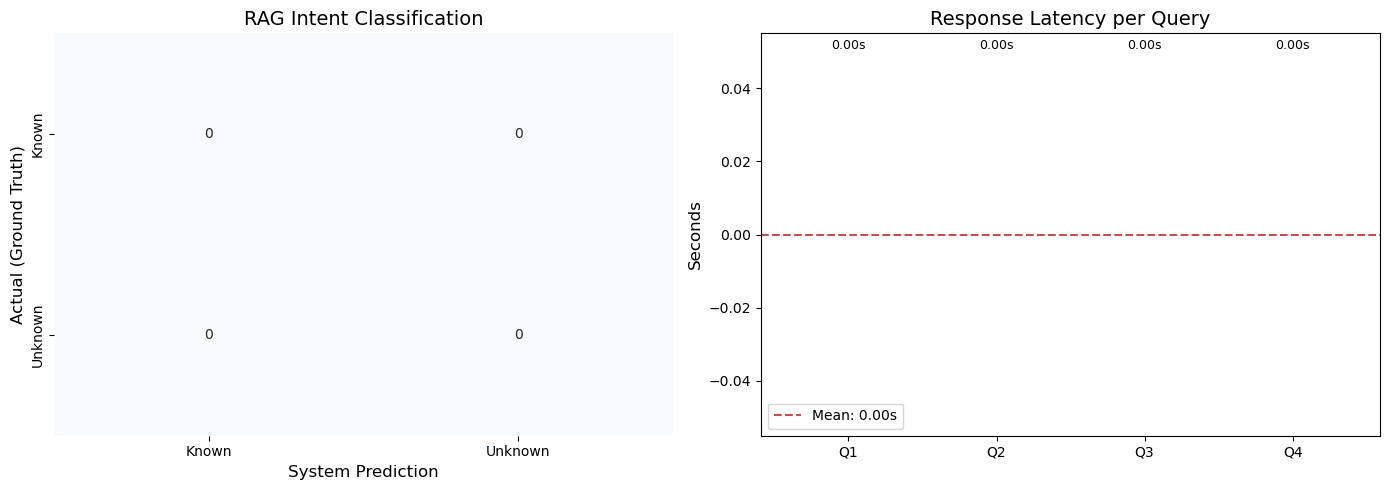

In [9]:
 
acc = accuracy_score(df_results["Ground_Truth"], df_results["Prediction"])
mean_latency = df_results["Latency_s"].mean()

print(f" Overall System Accuracy: {acc * 100:.1f}%")
print(f" Average Response Time: {mean_latency:.2f}s")

 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
labels = ["Known", "Unknown"]
cm = confusion_matrix(df_results["Ground_Truth"], df_results["Prediction"], labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax1, cbar=False)
ax1.set_title('RAG Intent Classification', fontsize=14)
ax1.set_ylabel('Actual (Ground Truth)', fontsize=12)
ax1.set_xlabel('System Prediction', fontsize=12)

# Plot 2: Latency Distribution
x_labels = [f"Q{i+1}" for i in range(len(df_results))]
bars = ax2.bar(x_labels, df_results["Latency_s"], color='#4C72B0')
ax2.axhline(mean_latency, color='#C44E52', linestyle='--', label=f'Mean: {mean_latency:.2f}s')

 
for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f"{yval:.2f}s", ha='center', va='bottom', fontsize=9)

ax2.set_title('Response Latency per Query', fontsize=14)
ax2.set_ylabel('Seconds', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.show()